In [1]:
from transformers import AutoModelForImageClassification, AutoImageProcessor
from datasets import load_dataset
from PIL import Image

import torch.nn.functional as F
import torch.backends.cudnn as cudnn
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt
import numpy as np

from tqdm.notebook import trange, tqdm
from dotenv import load_dotenv
import os

from shared import visualize_model, plot_bar
from shared_masking import *

load_dotenv()
cudnn.benchmark = True
plt.ion();

# 1. Using a Pre-trained ViT for Image Classification

In [2]:
MODEL = "facebook/deit-tiny-patch16-224"
DEVICE = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
SAMPLES_BASE="task-2-imagenet-samples"
BASE = "vit-task"
BASE_PLOTS = os.path.join(BASE, "plots")

os.makedirs(BASE_PLOTS, exist_ok=True)
print(f"Using {DEVICE=}")

Using DEVICE='cuda'


In [3]:
def load_model():
    processor = AutoImageProcessor.from_pretrained(MODEL)
    model = AutoModelForImageClassification.from_pretrained(MODEL, output_attentions=True, output_hidden_states=True).to(device=DEVICE)
    return processor, model

In [4]:
processor, model = load_model()

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

In [5]:
def read_from_disk(path):
    return Image.open(path)

def parse_label(path):
    return path.split("_")[-1].split(".")[0]

def read_samples():
    paths = os.listdir(SAMPLES_BASE)
    paths = [f"{SAMPLES_BASE}/{path}" for path in paths]
    samples = [(read_from_disk(path), parse_label(path).title()) for path in paths]
    return samples

def process_fn(inp):
    mean = np.array(processor.image_mean)
    std = np.array(processor.image_std)
    inp = std * inp + mean
    return inp

def forward(model, image):
    inputs = processor(images=image, return_tensors="pt").to(DEVICE)
    with torch.no_grad():
        outputs = model(**inputs)
    return inputs, outputs

def run_inference(model, image):
    inputs, outputs = forward(model, image)
    predicted_label = outputs.logits.argmax(-1).item()
    confidence = outputs.logits.softmax(-1).max(-1).values.item()
    return inputs.pixel_values[0], predicted_label, confidence

In [6]:
samples = read_samples()

  0%|          | 0/3 [00:00<?, ?it/s]

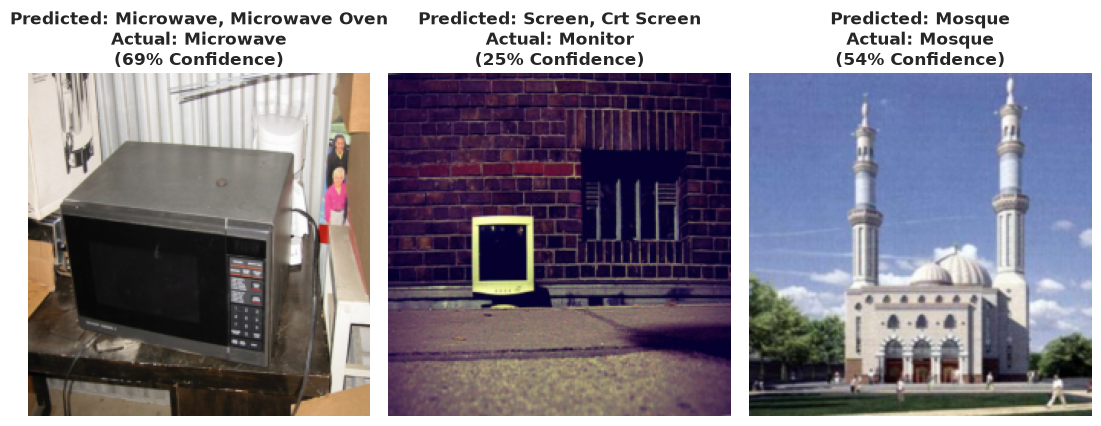

In [7]:
visualize_model(model, process_fn, samples, model.config.id2label, run_inference)
plt.savefig(os.path.join(BASE_PLOTS, "model_visualization.pdf"), bbox_inches="tight", dpi=300)
plt.show()

# 2. Visualizing Patch Attention and 3. Analyze the Attention Map

In [8]:
def minmax_norm(inp):
    return (inp - inp.min()) / (inp.max() - inp.min())

def overlay(inp, attn, processor, ax, title=None):
    inp = inp.numpy().transpose((1, 2, 0))
    attn = attn.numpy()
    
    mean = np.array(processor.image_mean)
    std = np.array(processor.image_std)
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    
    attn = minmax_norm(attn)
    
    ax.imshow(inp)
    ax.imshow(attn, alpha=attn, cmap="Reds")
    ax.axis("off")
    
    if title is not None:
        ax.set_title(title, fontweight="bold")

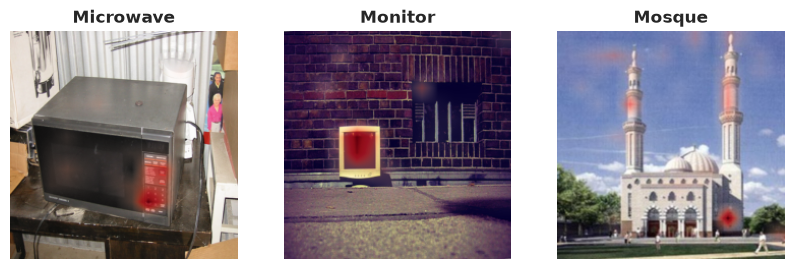

In [9]:
fig = plt.figure(figsize=(10,6))
samples = read_samples()
for i, (image, label) in enumerate(samples, start=1):
    inputs, outputs,  = forward(model, image)
    
    # this looks better than taking the average, the assignment allows selecting 1 head instead of taking the average
    cls_attentions = outputs.attentions[-1][:,0][:, 0, 1:]
    # cls_attentions = outputs.attentions[-1].mean(dim=1)[:, 0, 1:]    
    
    cls_attentions = cls_attentions[0]
    cls_attentions = cls_attentions.reshape((14,14))
    cls_attentions = F.interpolate(cls_attentions.unsqueeze(0).unsqueeze(0), scale_factor=16, mode="bilinear", align_corners=False)
    cls_attentions = cls_attentions[0,0]
    
    ax = fig.add_subplot(1,len(samples),i)
    overlay(inputs["pixel_values"][0].cpu(), cls_attentions.cpu(), processor, ax, title=label.title())
plt.savefig(os.path.join(BASE_PLOTS, "attention_visualization.pdf"), bbox_inches="tight", dpi=300)
plt.show()

# 4. Patch-Masking Experiment

  0%|          | 0/3 [00:00<?, ?it/s]

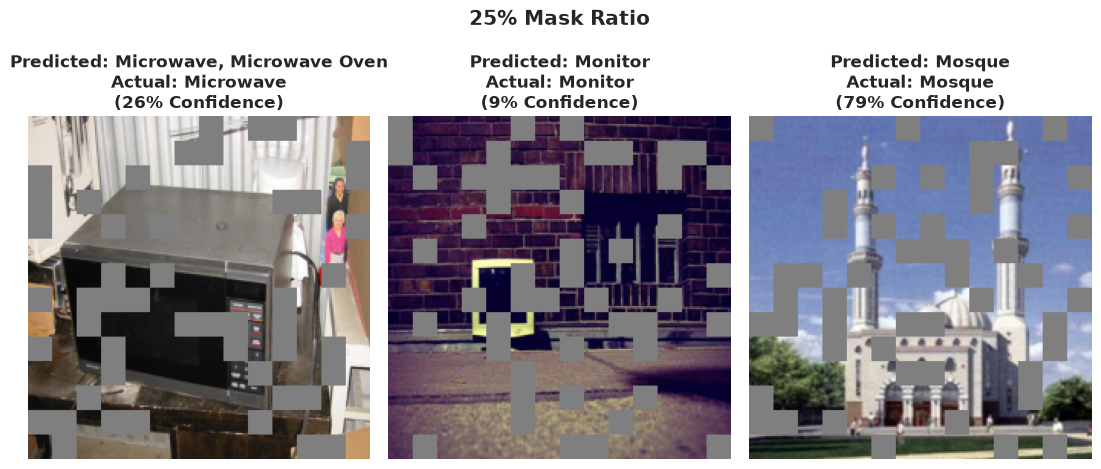

  0%|          | 0/3 [00:00<?, ?it/s]

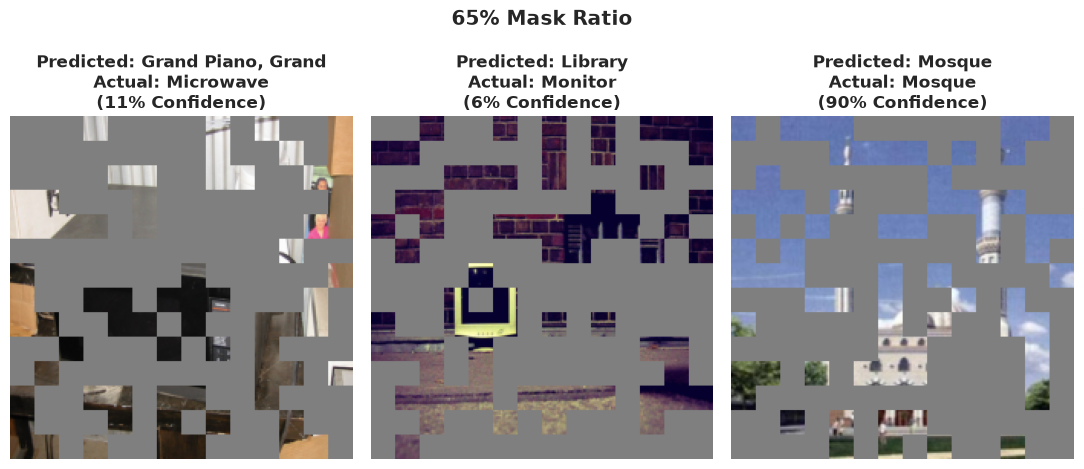

  0%|          | 0/3 [00:00<?, ?it/s]

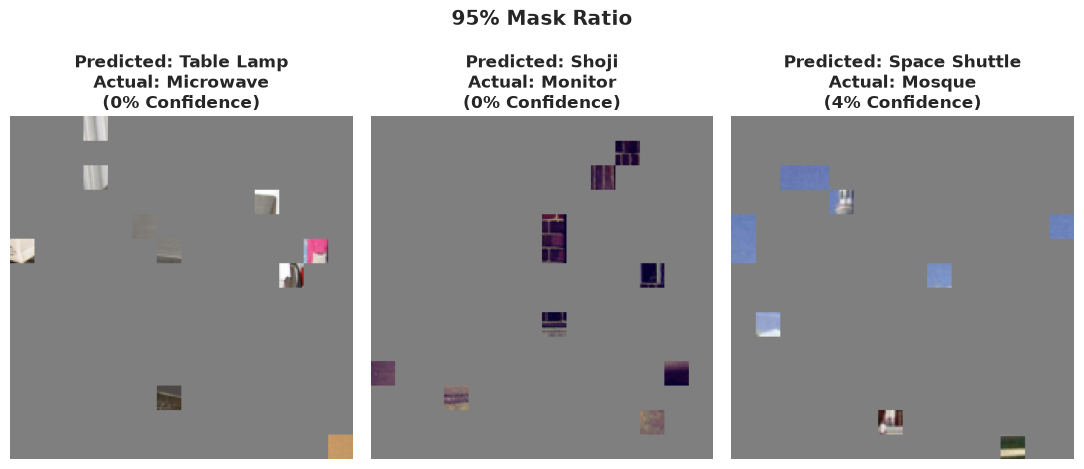

In [10]:
samples = read_samples()
for mask_ratio in [0.25, 0.65, 0.95]:
    def masked_run_inference(model, image):
        inputs = processor(images=image, return_tensors="pt").to(DEVICE)
        inputs.pixel_values = randomly_mask(inputs.pixel_values, mask_ratio=mask_ratio)
        with torch.no_grad():
            outputs = model(pixel_values=inputs.pixel_values)
        predicted_label = outputs.logits.argmax(-1).item()
        confidence = outputs.logits.softmax(-1).max(-1).values.item()
        return inputs.pixel_values[0], predicted_label, confidence
    
    visualize_model(model, process_fn, samples, model.config.id2label, masked_run_inference, title=f"{int(mask_ratio*100)}% Mask Ratio")
    plt.savefig(os.path.join(BASE_PLOTS, f"model_visualization_masked_{int(mask_ratio*100)}.pdf"), bbox_inches="tight", dpi=300)
    plt.show()

  0%|          | 0/3 [00:00<?, ?it/s]

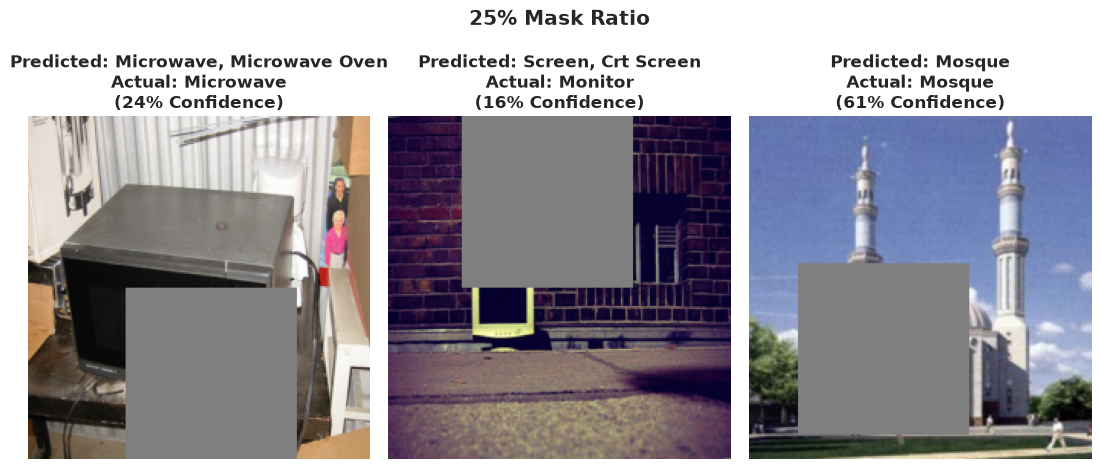

  0%|          | 0/3 [00:00<?, ?it/s]

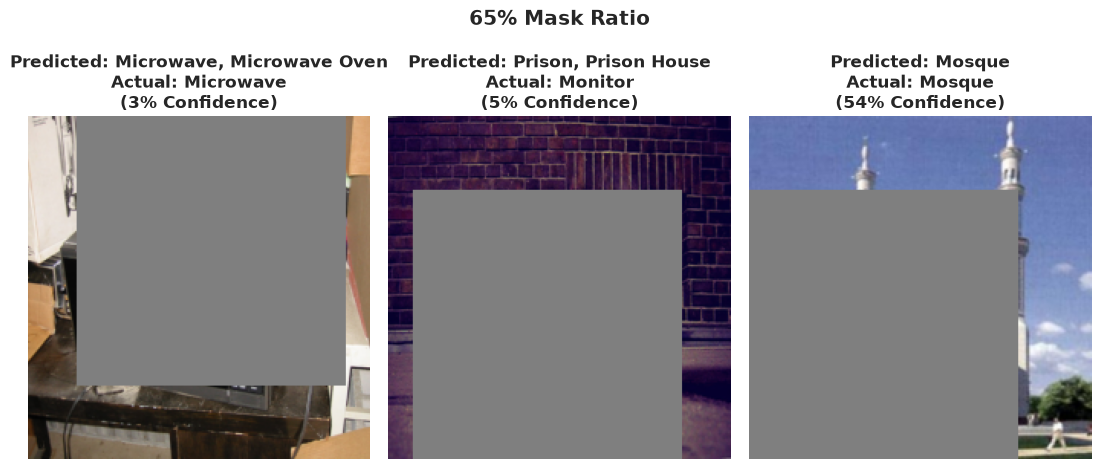

  0%|          | 0/3 [00:00<?, ?it/s]

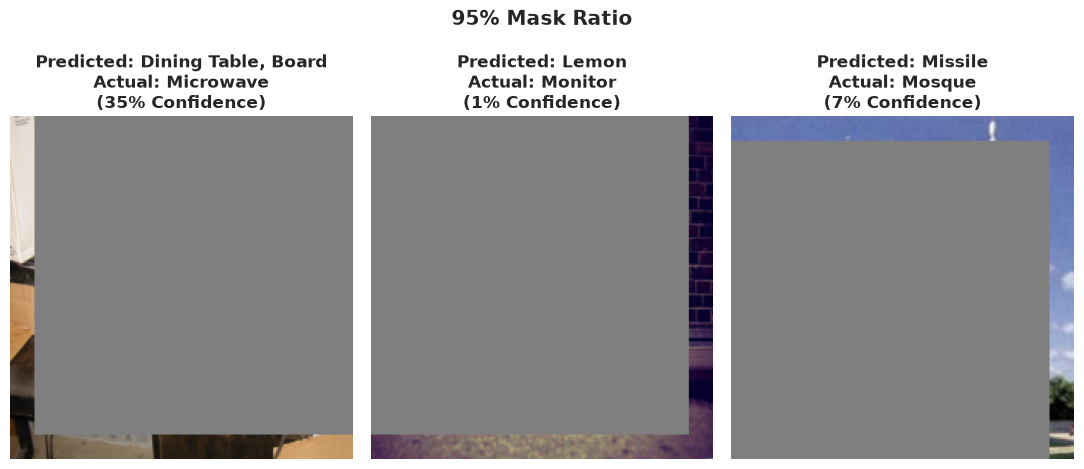

In [19]:
samples = read_samples()
for mask_ratio in [0.25, 0.65, 0.95]:
    def masked_run_inference(model, image):
        inputs = processor(images=image, return_tensors="pt").to(DEVICE)
        inputs.pixel_values = structurally_mask(inputs.pixel_values, mask_ratio=mask_ratio)
        with torch.no_grad():
            outputs = model(pixel_values=inputs.pixel_values)
        predicted_label = outputs.logits.argmax(-1).item()
        confidence = outputs.logits.softmax(-1).max(-1).values.item()
        return inputs.pixel_values[0], predicted_label, confidence

    visualize_model(model, process_fn, samples, model.config.id2label, masked_run_inference, title=f"{int(mask_ratio*100)}% Mask Ratio")
    plt.savefig(os.path.join(BASE_PLOTS, f"model_visualization_structured_masked_{int(mask_ratio*100)}.pdf"), bbox_inches="tight", dpi=300)
    plt.show()

In [12]:
class SimpleDataset(torch.utils.data.Dataset):
    def __init__(self, images, labels):
        self.images = images
        self.labels = labels

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        return self.images[idx], self.labels[idx]

def load_imagenet_val(batch_size, n_images=1000):
    ds = load_dataset(
        "ILSVRC/imagenet-1k",
        split="validation",
        streaming=True,
        token=os.environ["HF_TOKEN"],
    ).take(n_images)

    images, labels = [], []
    for x in tqdm(ds, total=n_images, desc="Loading ImageNet"):
        images.append(x["image"].convert("RGB"))
        labels.append(x["label"])

    def collate_fn(batch):
        return {
            "image": [x[0] for x in batch],
            "labels": torch.tensor([x[1] for x in batch]),
        }

    return DataLoader(
        SimpleDataset(images, labels),
        batch_size=batch_size,
        shuffle=False,
        collate_fn=collate_fn,
        num_workers=4,
        pin_memory=True,
        persistent_workers=True,
    )

@torch.inference_mode()
def compute_imagenet_top1_accuracy(
    model,
    processor,
    dataloader,
    mask_fn,
    total_iterations=None,
):
    model.eval()

    correct, total = 0, 0
    for batch in tqdm(dataloader, total=total_iterations, desc="Running inference..."):
        inputs = processor(images=batch["image"], return_tensors="pt")
        pixel_values = inputs.pixel_values

        pixel_values = mask_fn(pixel_values, mask_ratio=0.5).to(DEVICE, non_blocking=True)
        labels = batch["labels"].to(DEVICE, non_blocking=True)

        outputs = model(pixel_values=pixel_values)

        correct += (outputs.logits.argmax(dim=1) == labels).sum().item()
        total += labels.numel()

    return correct / total

In [13]:
N_IMAGES = 1000
BATCH_SIZE = 8
total_iterations = (N_IMAGES + BATCH_SIZE - 1) // BATCH_SIZE

In [14]:
dataloader = load_imagenet_val(batch_size=BATCH_SIZE, n_images=N_IMAGES)

Resolving data files:   0%|          | 0/294 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/28 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/294 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/28 [00:00<?, ?it/s]

Loading ImageNet:   0%|          | 0/1000 [00:00<?, ?it/s]

In [15]:
random_acc = compute_imagenet_top1_accuracy(model, processor, dataloader, randomly_mask, total_iterations=total_iterations)
print(f"Random-mask Top-1 accuracy: {random_acc:.4f}")

Running inference...:   0%|          | 0/125 [00:00<?, ?it/s]

Random-mask Top-1 accuracy: 0.5590


In [16]:
structure_acc = compute_imagenet_top1_accuracy(model, processor, dataloader, structurally_mask, total_iterations=total_iterations)
print(f"Structurally-mask Top-1 accuracy: {structure_acc:.4f}")

Running inference...:   0%|          | 0/125 [00:00<?, ?it/s]

Structurally-mask Top-1 accuracy: 0.4290


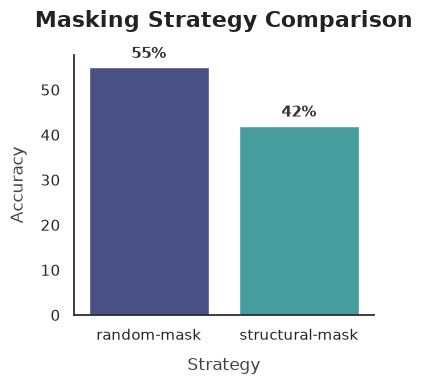

In [17]:
plot_bar(list(map(lambda x: int(x*100), [random_acc, structure_acc])), ["random-mask", "structural-mask"], "Masking Strategy Comparison", "Strategy", "Accuracy")
plt.savefig(os.path.join(BASE_PLOTS, "masking_strategy_comparison.pdf"), bbox_inches="tight", dpi=300)
plt.show()